# Restaurant Success Analysis in Istanbul

## Introduction

This project analyzes restaurant success in Istanbul by focusing on district and cuisine type.
The dataset includes restaurants from Kadıköy, Beşiktaş, and Şişli.
Success is measured using a combined score based on rating and number of reviews.

## Data Collection

The data was collected from Google Maps.
The dataset contains restaurant name, district, cuisine type, rating, number of reviews, and price level.

In [135]:
import pandas as pd
from google.colab import files

In [136]:
uploaded = files.upload()

Saving restaurants (1).xlsx to restaurants (1) (14).xlsx


## Data Cleaning

In this section, the dataset is prepared for analysis.
Column names are simplified, ratings are converted into numeric format, price level is encoded numerically, and a success score is created.

In [137]:
df = pd.read_excel("restaurants (1).xlsx")

In [138]:
df.columns = ["name","district","cuisine","rating","reviews","price"]

In [139]:
df['rating'] = df['rating'].astype(str).str.replace(',', '.').astype(float)
df['reviews'] = df['reviews'].astype(int)
df['price'] = df['price'].astype(str).apply(lambda x: len(x))

In [140]:
df['success_score'] = df['rating'] * df['reviews']

## Exploratory Data Analysis

This section presents visual exploration of the data, including distributions of key variables and comparisons across districts and cuisine types.

In [141]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

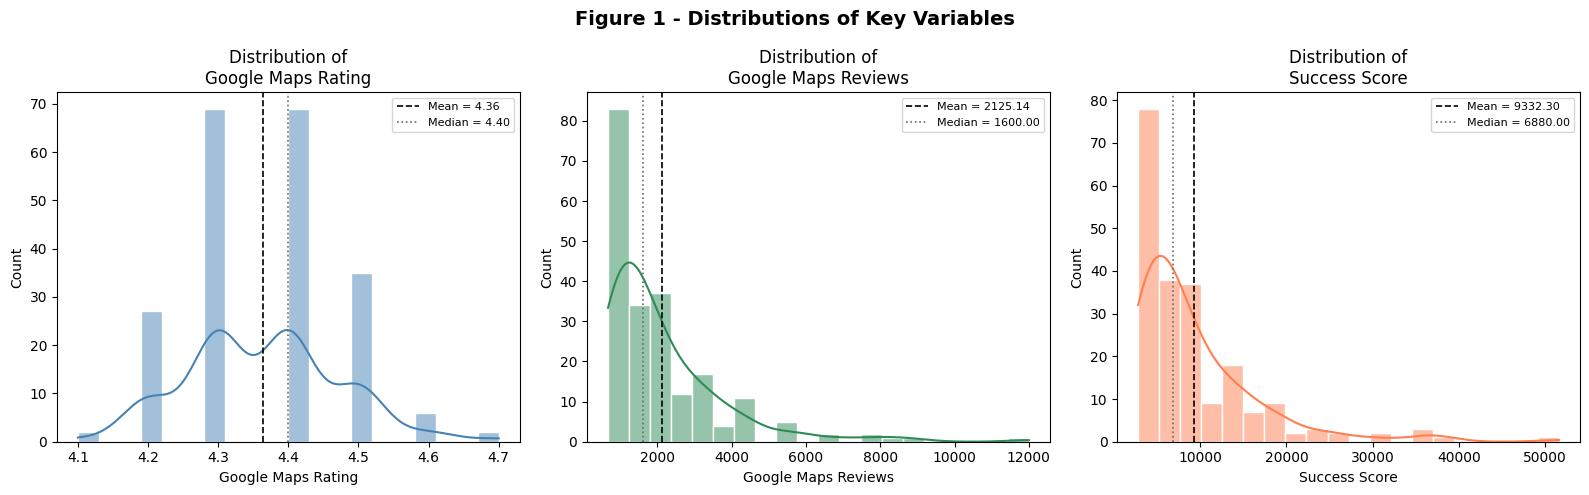

In [142]:
fig1, axes = plt.subplots(1, 3, figsize=(16, 5))
fig1.suptitle("Figure 1 - Distributions of Key Variables", fontsize=14, fontweight="bold")

for ax, (col, xlabel, color) in zip(axes, [
    ("rating", "Google Maps Rating", "steelblue"),
    ("reviews", "Google Maps Reviews", "seagreen"),
    ("success_score", "Success Score", "coral")
]):
    sns.histplot(df[col], kde=True, color=color, bins=20, edgecolor="white", ax=ax)
    ax.axvline(df[col].mean(), color="black", ls="--", lw=1.2,
               label=f"Mean = {df[col].mean():.2f}")
    ax.axvline(df[col].median(), color="dimgray", ls=":", lw=1.2,
               label=f"Median = {df[col].median():.2f}")
    ax.set_title(f"Distribution of\n{xlabel}")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

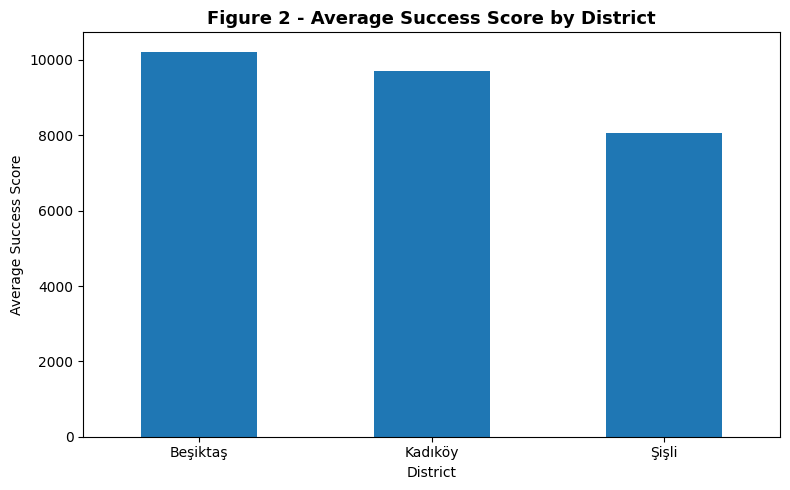

In [143]:
# Figure 2: Average success by district
district_avg = df.groupby("district")["success_score"].mean().sort_values(ascending=False)

fig2, ax = plt.subplots(figsize=(8, 5))
district_avg.plot(kind="bar", ax=ax)

ax.set_title("Figure 2 - Average Success Score by District", fontsize=13, fontweight="bold")
ax.set_xlabel("District")
ax.set_ylabel("Average Success Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

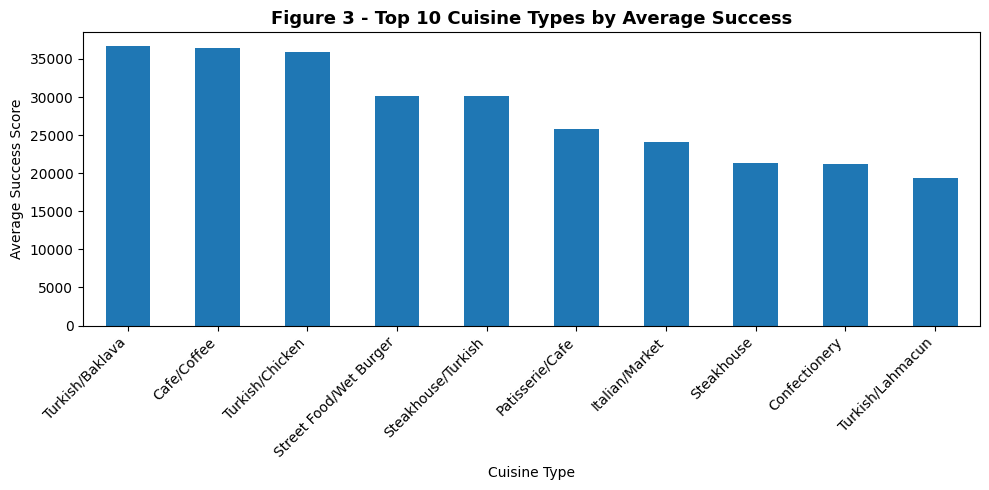

In [144]:
# Figure 3: Top 10 cuisine by success
top_cuisines = df.groupby("cuisine")["success_score"].mean().sort_values(ascending=False).head(10)

fig3, ax = plt.subplots(figsize=(10, 5))
top_cuisines.plot(kind="bar", ax=ax)

ax.set_title("Figure 3 - Top 10 Cuisine Types by Average Success", fontsize=13, fontweight="bold")
ax.set_xlabel("Cuisine Type")
ax.set_ylabel("Average Success Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

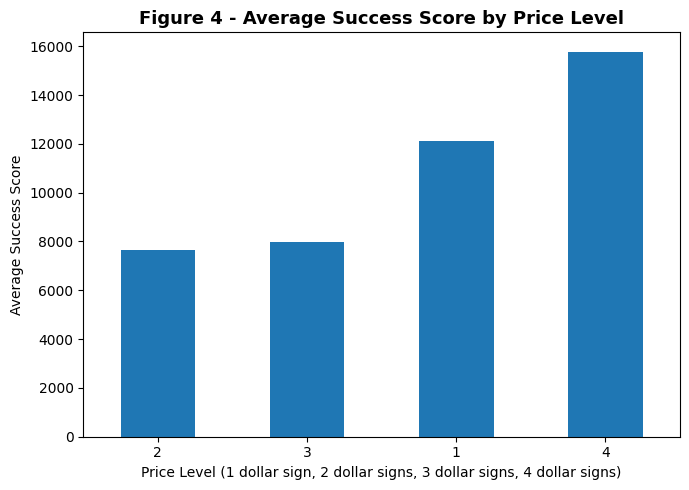

In [145]:
# Figure 4: Average success by price level
price_avg = df.groupby("price")["success_score"].mean().sort_values()

fig4, ax = plt.subplots(figsize=(7, 5))
price_avg.plot(kind="bar", ax=ax)

ax.set_title("Figure 4 - Average Success Score by Price Level", fontsize=13, fontweight="bold")
ax.set_xlabel("Price Level (1 dollar sign, 2 dollar signs, 3 dollar signs, 4 dollar signs)")
ax.set_ylabel("Average Success Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Regression Analysis

A regression model is used to evaluate the effect of district and cuisine type on restaurant success.

In [146]:
X = pd.get_dummies(df[['district', 'cuisine']], drop_first=True)
X.head()
X = X.astype(int)

In [147]:
import statsmodels.api as sm

X = sm.add_constant(X)
y = df['success_score']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          success_score   R-squared:                       0.678
Model:                            OLS   Adj. R-squared:                  0.387
Method:                 Least Squares   F-statistic:                     2.335
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           8.89e-06
Time:                        11:26:04   Log-Likelihood:                -2048.5
No. Observations:                 210   AIC:                             4297.
Df Residuals:                     110   BIC:                             4632.
Df Model:                          99                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const 

## Hypothesis Testing

To test whether district has an effect on restaurant success, a one-way ANOVA test is applied.

- **Null Hypothesis (H0):** District has no effect on restaurant success.
- **Alternative Hypothesis (H1):** District affects restaurant success.

In [148]:
from scipy import stats

anova = stats.f_oneway(
    df[df["district"]=="Kadıköy"]["success_score"],
    df[df["district"]=="Beşiktaş"]["success_score"],
    df[df["district"]=="Şişli"]["success_score"]
)

print("p-value:", anova.pvalue)

p-value: 0.19583877329939003


The ANOVA test results show that the p-value is greater than 0.05 (p = 0.196), indicating that there is no statistically significant difference between districts in terms of restaurant success. Therefore, we fail to reject the null hypothesis.

This suggests that district does not have a significant impact on restaurant success in this dataset.

This result is consistent with the regression analysis, where district variables were also found to be statistically insignificant. Both methods confirm that location does not play a major role in determining restaurant success.

## Conclusion

This project analyzed restaurant success in Istanbul by examining the effects of district and cuisine type.
Exploratory data analysis revealed some visible differences in average success across districts. However, both hypothesis testing (ANOVA) and regression analysis showed that these differences are not statistically significant, indicating that district does not have a meaningful impact on restaurant success.

In contrast, cuisine type was found to be a key determinant of success. Several categories, such as café/coffee, Turkish desserts, and fast-food items, demonstrated significantly higher success scores. These findings suggest that customer preferences and food trends play a more important role than geographical location in determining restaurant success.